# Model Explainability (SHAP)

Objective:
- Explain model predictions
- Identify most important features
- Provide transparency for fraud detection

In [20]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
import joblib

In [21]:
df = pd.read_csv("../data/processed/final_dataset_with_graph.csv")

df.head()

,consumer_id,timestamp,kwh,voltage,current,power_factor,theft_label,transformer_id,total_kwh,temperature,...,rolling_min_24h,sudden_drop_flag,isolation_anomaly_flag,isolation_score,lof_anomaly_flag,optimized_iso_flag,theft_probability,degree_centrality,transformer_theft_ratio,graph_suspicion_score
0,1,2024-01-01 00:00:00,1.408501,231.134680,6.600922,0.970170,0,T7,46.629769,25.086067,...,1.408501,0,1,0.010488,0,1,7.873644e-06,0.004785,0.00195,0.003084
1,1,2024-01-01 01:00:00,1.590901,226.709743,6.022453,0.949561,0,T7,49.026706,25.086067,...,1.408501,0,0,-0.009386,0,0,3.358269e-07,0.004785,0.00195,0.003084
2,1,2024-01-01 02:00:00,1.539829,233.289587,6.373323,0.967279,0,T7,50.220320,25.086067,...,1.408501,0,0,-0.007120,0,0,3.575445e-07,0.004785,0.00195,0.003084
3,1,2024-01-01 03:00:00,1.215253,233.507623,5.297672,0.879270,0,T7,53.799312,25.086067,...,1.215253,0,0,-0.005006,0,0,1.350626e-06,0.004785,0.00195,0.003084
4,1,2024-01-01 04:00:00,2.131333,231.189122,8.212522,0.987504,0,T7,54.309090,25.086067,...,1.215253,0,1,0.014058,1,1,1.115324e-06,0.004785,0.00195,0.003084


In [22]:
model = joblib.load("../models/classification/xgb_model.pkl")

model

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [23]:
feature_columns = [
    "kwh",
    "voltage",
    "current",
    "power_factor",
    "temperature",
    "humidity",
    "hour",
    "day",
    "month",
    "day_of_week",
    "is_weekend",
    "is_night",
    "is_peak_hour",
    "load_ratio",
    "rolling_mean_24h",
    "rolling_std_24h",
    "lag_1",
    "lag_24",
    "diff_1",
    "diff_24",
    "z_score",
    "transformer_deviation",
    "rolling_max_24h",
    "rolling_min_24h",
    "sudden_drop_flag",
    "isolation_score"
]

X = df[feature_columns]

In [24]:
# Use smaller sample for SHAP (avoids memory issues)
X_sample = X.sample(1000, random_state=42)

X_sample.head()

,kwh,voltage,current,power_factor,temperature,humidity,hour,day,month,day_of_week,...,lag_1,lag_24,diff_1,diff_24,z_score,transformer_deviation,rolling_max_24h,rolling_min_24h,sudden_drop_flag,isolation_score
124821,1.327494,229.512002,5.501628,0.924110,28.243148,73.949504,21,10,2,5,...,1.068982,0.999165,0.258511,0.328329,0.486630,-0.010849,1.718266,0.850805,0,-0.100868
40368,0.854943,231.636702,4.171559,0.851022,25.258098,62.556412,0,3,1,2,...,0.920795,0.932755,-0.065852,-0.077812,-0.537992,-0.020301,1.735034,0.612373,0,-0.068064
118349,2.011510,228.655512,8.047535,0.981414,26.025522,78.351555,5,12,1,4,...,1.790985,1.607417,0.220525,0.404093,1.698915,-0.000543,2.011510,1.035460,0,-0.061109
224576,3.193874,231.808788,13.254545,0.921292,29.203092,66.046594,8,27,2,1,...,2.619777,2.942399,0.574097,0.251475,1.832381,0.015108,3.193874,1.796941,0,-0.036313
126881,0.000000,229.833519,-0.901736,0.898380,25.601040,58.963776,17,7,1,6,...,0.327479,0.091121,-0.327479,-0.091121,-1.918129,-0.043478,1.183832,0.000000,0,0.089156


In [26]:
# Define prediction function
def predict_fn(data):
    return model.predict_proba(data)[:, 1]

# Create SHAP explainer using prediction function
explainer = shap.Explainer(predict_fn, X_sample)

# Compute SHAP values
shap_values = explainer(X_sample)

PermutationExplainer explainer: 1001it [01:42,  9.76it/s]                          


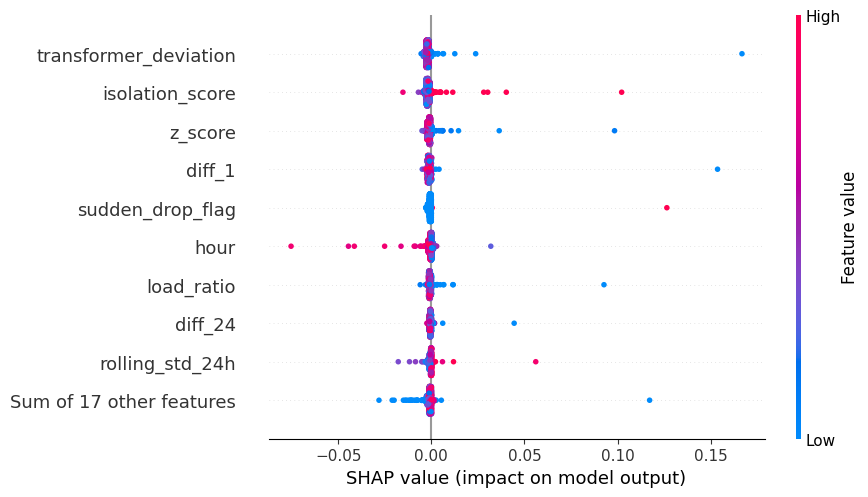

In [27]:
shap.plots.beeswarm(shap_values)

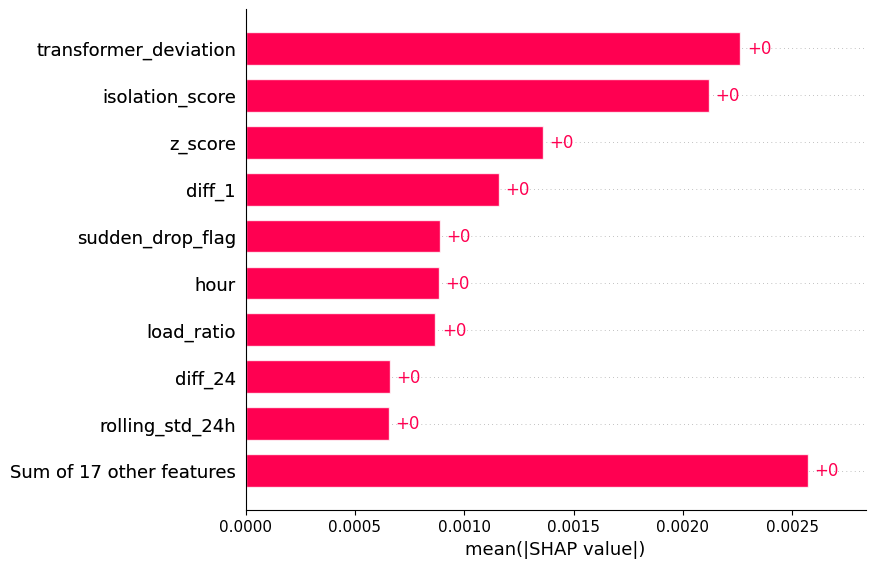

In [28]:
shap.plots.bar(shap_values)

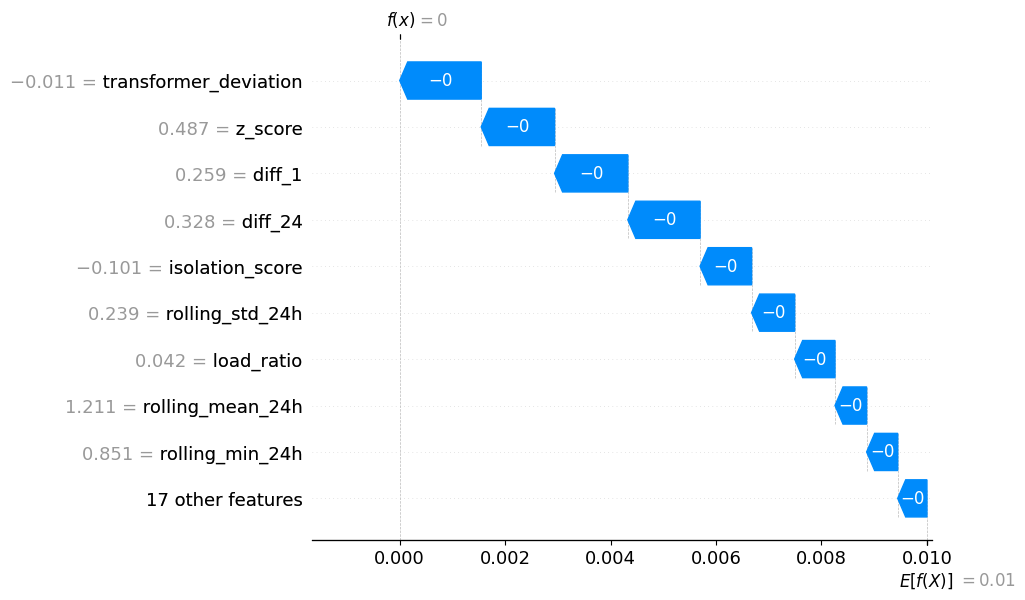

In [29]:
shap.plots.waterfall(shap_values[0])

In [30]:
# Calculate mean absolute SHAP value
importance_df = pd.DataFrame({
    "feature": feature_columns,
    "mean_abs_shap": np.abs(shap_values.values).mean(axis=0)
}).sort_values(by="mean_abs_shap", ascending=False)

importance_df.head(10)

,feature,mean_abs_shap
21,transformer_deviation,0.002263
25,isolation_score,0.002120
20,z_score,0.001360
18,diff_1,0.001159
24,sudden_drop_flag,0.000890
6,hour,0.000883
13,load_ratio,0.000868
19,diff_24,0.000658
15,rolling_std_24h,0.000655
0,kwh,0.000617


In [31]:
importance_df.to_csv("../reports/shap_feature_importance.csv", index=False)

print("SHAP feature importance saved.")

SHAP feature importance saved.


## Explainability Insights

1. Isolation score strongly influences theft prediction.
2. Transformer deviation increases suspicion probability.
3. Sudden drop indicators significantly impact decisions.
4. Rolling statistics capture behavioral deviations.
5. Load ratio indicates abnormal transformer contribution.

The model is:
- Transparent
- Explainable
- Suitable for regulatory review

## Model Explainability Summary

We implemented SHAP to:

- Provide global feature importance
- Explain individual predictions
- Increase trust in AI system
- Support regulatory compliance

Next Step:
- Business Impact Analysis
- Final Ensemble Risk Scoring